Learning rate: 5e-5
Subset size: 1000
Decoding: beam search (num_beams=3)
Results: BLEU = 0.093, ROUGE-L = 0.397, Train Loss = 2.77 (best on all 3 metrics)

Markdown: Week 2 — Multimodal Model Development (Baseline)
Cell: imports + config
Cell: load captions_df, train/val split

Markdown: Day 1 — Zero-shot BLIP
Cell: zero-shot inference on 5-10 sample images

Markdown: Day 2 — Baseline evaluation setup
Cell: BLEU/ROUGE functions + zero-shot scores on val subset

Markdown: Day 3 — MLflow setup + light fine-tuning intro
Cell: brief note/first MLflow run reference

Markdown: Day 4 — Fine-tuning experiments (3 configs)
Cell: comparison table (from your Cell 11)
[Embed MLflow dashboard screenshot as markdown image]
Markdown: written note on which config won and why

Markdown: Day 5 — Selected baseline
Cell: final config + save baseline model to disk
Cell: demo — captions on 5 sample images (grid plot)

In [3]:
import os
import torch
from PIL import Image
from transformers import BlipProcessor, BlipForConditionalGeneration
import pandas as pd
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
IMAGES_DIR = r"C:\Users\Lenovo\Internship\data\Flickr8k\images"

In [4]:
captions_df = pd.read_csv(
    r"C:\Users\Lenovo\Internship\data\Flickr8k\captions.txt",
    sep="|"
)

unique_images = captions_df["image_name"].unique()
train_images, val_images = train_test_split(unique_images, test_size=0.1, random_state=42)

train_df = captions_df[captions_df["image_name"].isin(train_images)].reset_index(drop=True)
val_df = captions_df[captions_df["image_name"].isin(val_images)].reset_index(drop=True)

print("Loaded. Val rows:", len(val_df))

Loaded. Val rows: 4050


In [5]:
class FlickrCaptionDataset(Dataset):
    def __init__(self, df, images_dir, processor):
        self.df = df.reset_index(drop=True)
        self.images_dir = images_dir
        self.processor = processor
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(os.path.join(self.images_dir, row["image_name"])).convert("RGB")
        encoding = self.processor(images=image, text=row["caption_text"],
            padding="max_length", truncation=True, max_length=32, return_tensors="pt")
        return {k: v.squeeze(0) for k, v in encoding.items()}

baseline_processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
baseline_model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base").to(device)

for param in baseline_model.vision_model.parameters():
    param.requires_grad = False

subset_df = train_df.sample(n=1000, random_state=42)
dataset = FlickrCaptionDataset(subset_df, IMAGES_DIR, baseline_processor)
loader = DataLoader(dataset, batch_size=4, shuffle=True)

optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, baseline_model.parameters()), lr=5e-5)

baseline_model.train()
for i, batch in enumerate(loader):
    batch = {k: v.to(device) for k, v in batch.items()}
    outputs = baseline_model(**batch, labels=batch["input_ids"])
    loss = outputs.loss
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if i % 20 == 0:
        print(f"batch {i}/{len(loader)}, loss={loss.item():.4f}")

print("Training done.")

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

batch 0/250, loss=9.2721
batch 20/250, loss=4.7384
batch 40/250, loss=3.3549
batch 60/250, loss=2.3120
batch 80/250, loss=1.6207
batch 100/250, loss=0.7828
batch 120/250, loss=1.3674
batch 140/250, loss=1.1037
batch 160/250, loss=0.9200
batch 180/250, loss=0.9303
batch 200/250, loss=0.8732
batch 220/250, loss=1.0476
batch 240/250, loss=1.0286
Training done.


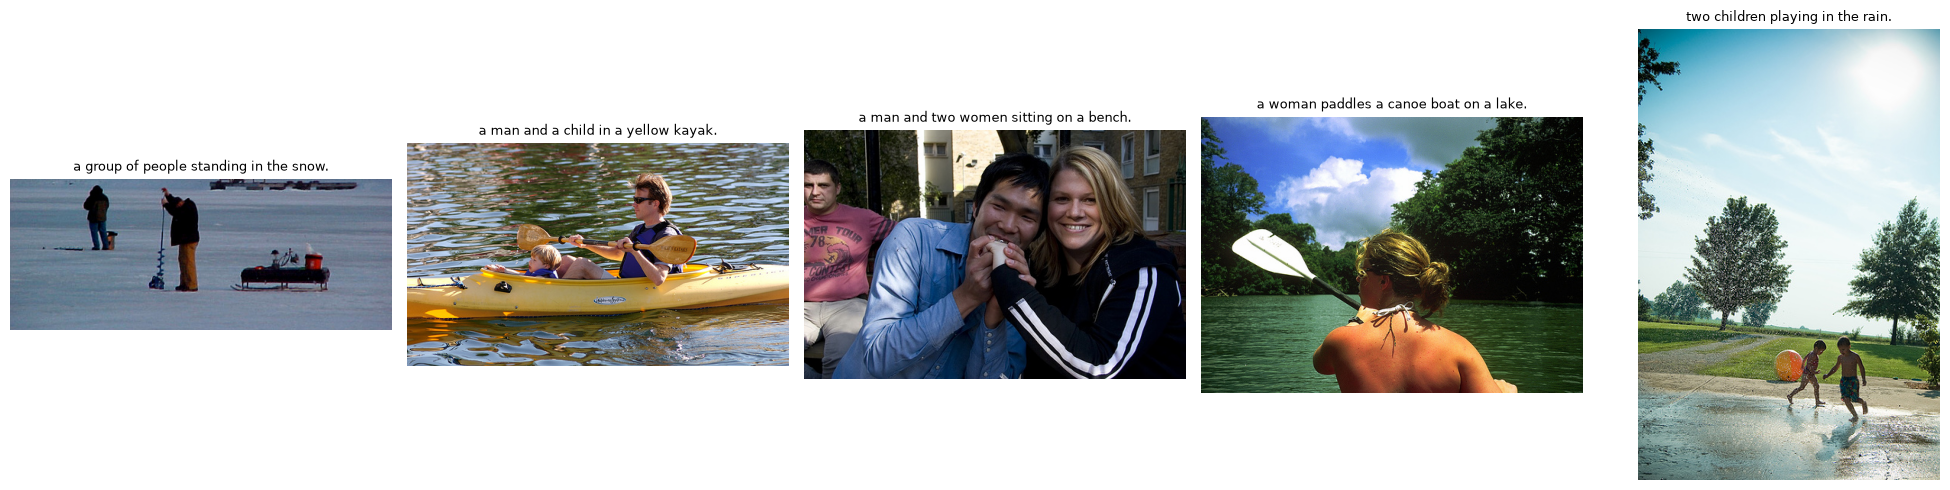

Saved: baseline_demo_captions.png


In [6]:
sample_images = val_df["image_name"].unique()[:5]
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

baseline_model.eval()
for ax, img_name in zip(axes, sample_images):
    image = Image.open(os.path.join(IMAGES_DIR, img_name)).convert("RGB")
    inputs = baseline_processor(images=image, return_tensors="pt").to(device)
    out = baseline_model.generate(**inputs, num_beams=3, max_new_tokens=25)
    caption = baseline_processor.decode(out[0], skip_special_tokens=True)
    ax.imshow(image)
    ax.set_title(caption, fontsize=9, wrap=True)
    ax.axis("off")

plt.tight_layout()
plt.savefig("baseline_demo_captions.png", dpi=150)
plt.show()
print("Saved: baseline_demo_captions.png")

In [7]:
save_dir = r"C:\Users\Lenovo\Internship\models\week2_baseline_blip"
os.makedirs(save_dir, exist_ok=True)

baseline_model.save_pretrained(save_dir)
baseline_processor.save_pretrained(save_dir)

print("Model saved to:", save_dir)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: C:\Users\Lenovo\Internship\models\week2_baseline_blip


# Week 2 Write-up — Multimodal Model Development (Baseline)

## 1. Baseline Model Description
- Base model: Salesforce/blip-image-captioning-base
- Approach: vision encoder frozen; only text decoder fine-tuned
- Dataset: Flickr8k, split by unique image into train/val (90/10) to avoid leakage

## 2. MLflow Run Comparison Summary

| Run                           Learning Rate | Subset Size | Decoding | BLEU | ROUGE-L | Train Loss |

| run1_lr5e-5_greedy               5e-5            500         greedy    0.078 | 0.375  | 4.52 |
| run2_lr1e-5_beam3                1e-5            500         beam(3)   0.092 | 0.385  | 6.41 |
| run3_lr5e-5_subset1000_beam3     5e-5           1000         beam(3)   0.093 | 0.397  | 2.77 |

Run 3 achieved the best BLEU and ROUGE-L scores with the lowest training
loss, benefiting from double the training data. Comparing run1 vs run2
shows beam search decoding outperforms greedy decoding even with a much
lower learning rate — decoding strategy matters more than learning rate
in this setup.

## 3. Chosen Final Baseline
- Learning rate: 5e-5
- Subset size: 1000
- Decoding: beam search, num_beams=3
- BLEU: 0.093 | ROUGE-L: 0.397

This model is saved at `models/week2_baseline_blip/` and will be the
baseline going into Week 3.

## 4. Demo — Sample Captions
![Baseline demo captions]